# EDA on Mall Customer Segmentation Data

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.shape

(200, 5)

In [4]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
df.describe(include='object')

,Gender
count,200
unique,2
top,Female
freq,112


In [8]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### No Missing Values in the dataset

In [9]:
df.duplicated().sum()

np.int64(0)

### No Duplicate Values in the dataset

In [10]:
df.select_dtypes(include=np.number).head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,2,21,15,81
2,3,20,16,6
3,4,23,16,77
4,5,31,17,40


## Data Visualization

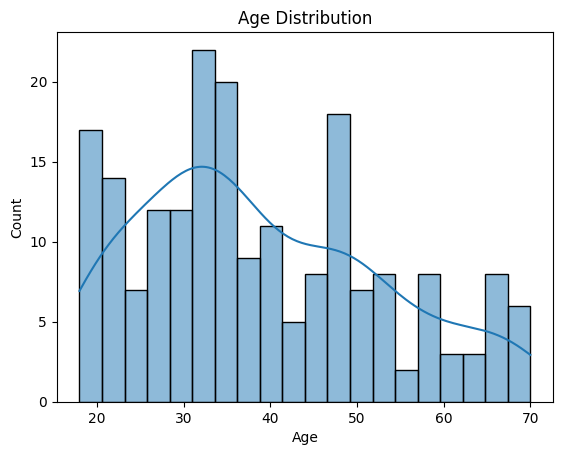

In [11]:
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

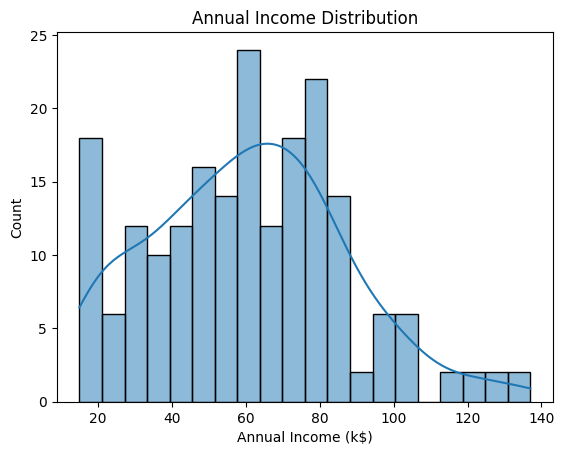

In [12]:
sns.histplot(df["Annual Income (k$)"], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.show()

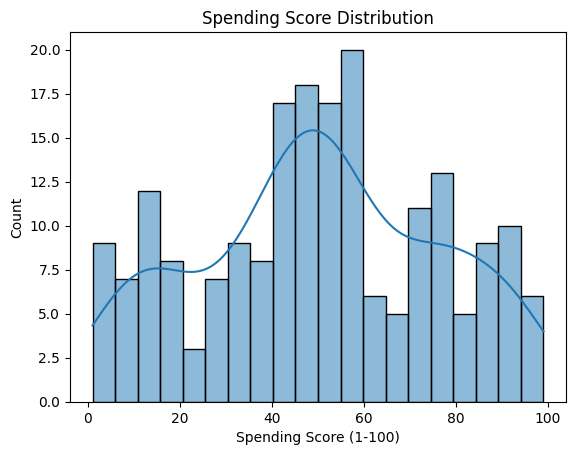

In [13]:
sns.histplot(df["Spending Score (1-100)"], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.show()

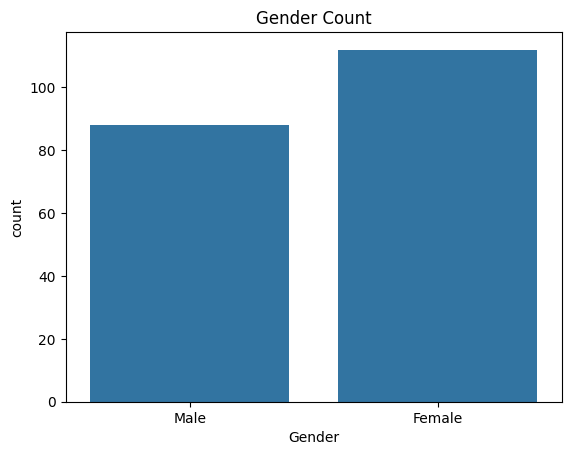

In [14]:
sns.countplot(x="Gender", data=df)
plt.title("Gender Count")
plt.show()

In [15]:
df["Gender"].value_counts(normalize=True)*100

Gender
Female    56.0
Male      44.0
Name: proportion, dtype: float64

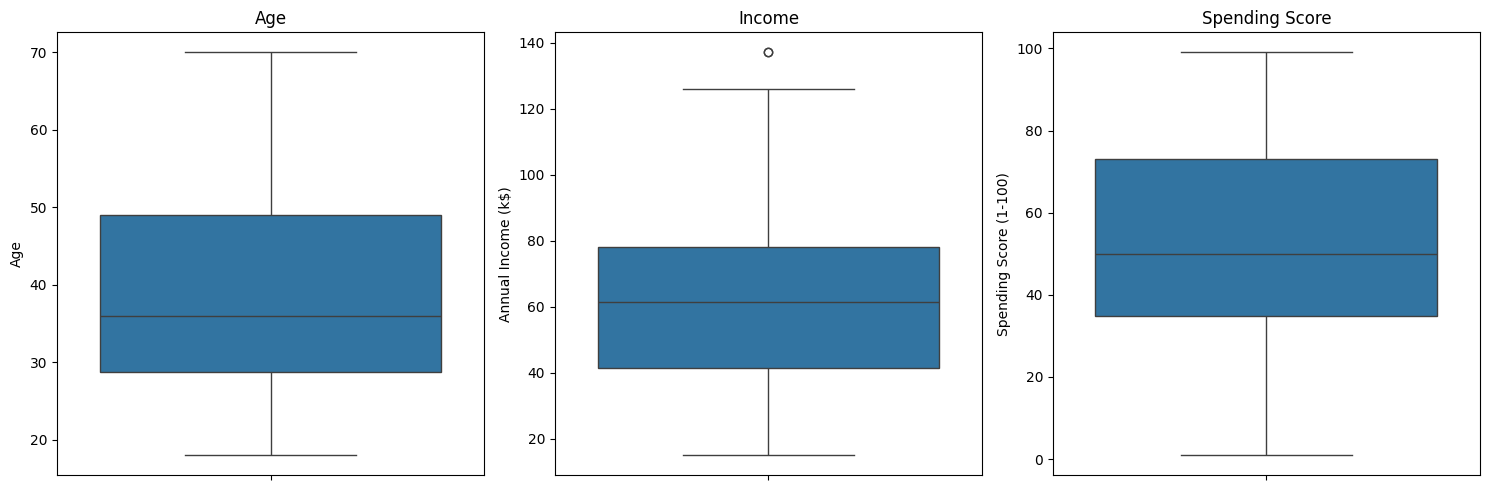

In [16]:
fig, ax = plt.subplots(1,3, figsize=(15,5))

sns.boxplot(y=df["Age"], ax=ax[0])
ax[0].set_title("Age")

sns.boxplot(y=df["Annual Income (k$)"], ax=ax[1])
ax[1].set_title("Income")

sns.boxplot(y=df["Spending Score (1-100)"], ax=ax[2])
ax[2].set_title("Spending Score")

plt.tight_layout()
plt.show()

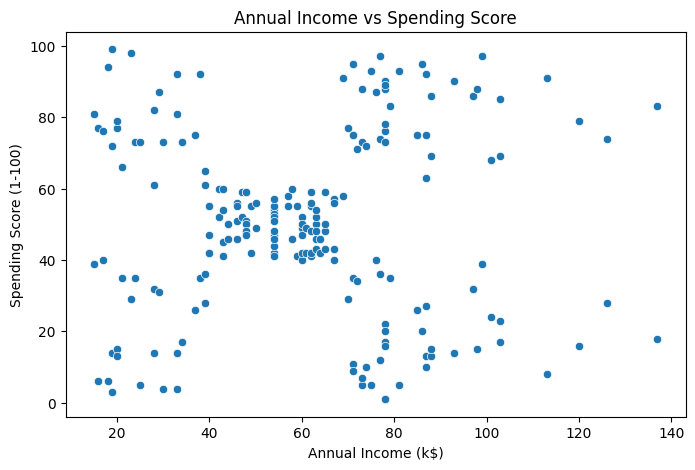

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    data=df
)

plt.title("Annual Income vs Spending Score")
plt.show()

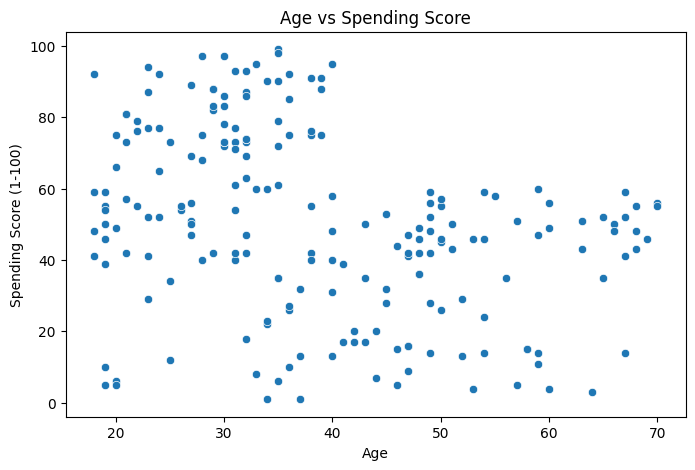

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="Age",
    y="Spending Score (1-100)",
    data=df
)

plt.title("Age vs Spending Score")
plt.show()

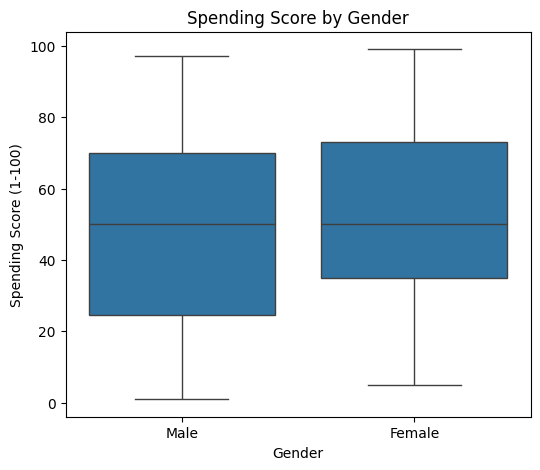

In [19]:
plt.figure(figsize=(6,5))
sns.boxplot(
    x="Gender",
    y="Spending Score (1-100)",
    data=df
)

plt.title("Spending Score by Gender")
plt.show()

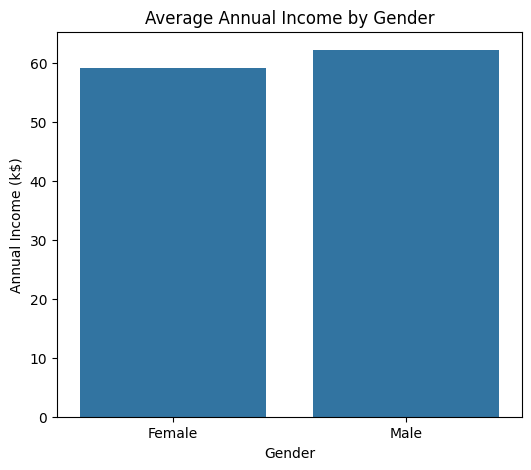

In [20]:
avg_income = df.groupby("Gender")["Annual Income (k$)"].mean().reset_index()

plt.figure(figsize=(6,5))
sns.barplot(
    x="Gender",
    y="Annual Income (k$)",
    data=avg_income
)

plt.title("Average Annual Income by Gender")
plt.show()

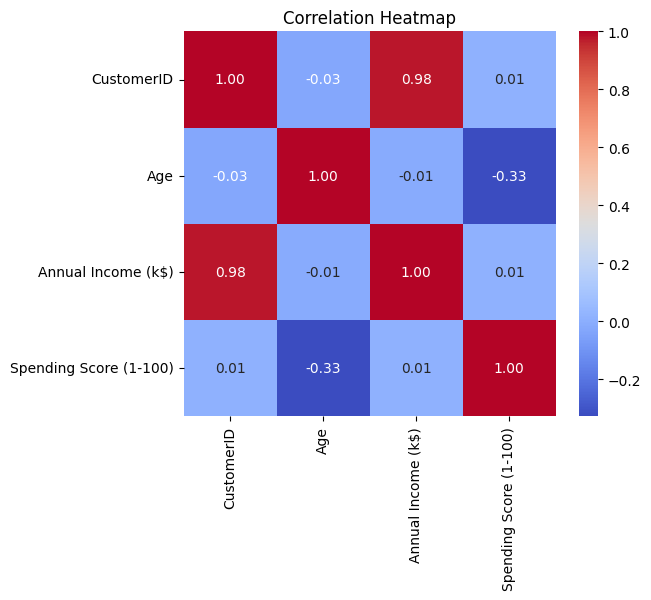

In [21]:
plt.figure(figsize=(6,5))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

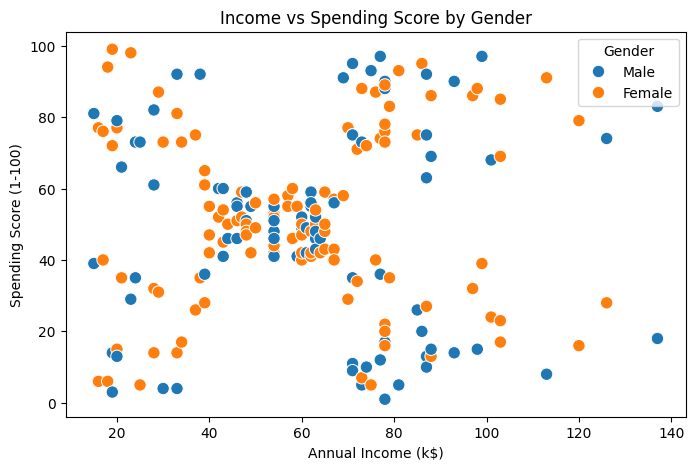

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Gender",
    data=df,
    s=80
)

plt.title("Income vs Spending Score by Gender")
plt.show()

## Summary

- No missing values or duplicate records were found.
- Customer distribution is nearly balanced between males and females.
- Most customers are between 20–40 years old.
- Annual income has a weak correlation with spending score.
- Dataset is suitable for clustering.